
# Session 12 — 32 Virtual GPUs: Data Parallel / ZeRO-0, ZeRO-1, ZeRO-2, ZeRO-3

This notebook is a **simulation and accounting demo**, not a claim that a free Colab T4 has 32 physical GPUs.

**32 logical ranks ("virtual GPUs")** on one Colab T4 (or CPU fallback). A small model sees 32 different micro-batches, one per virtual rank. Compute the local gradients, then simulate the collective/update behavior of:

- **ZeRO-0 / ordinary data parallel** — nothing sharded
- **ZeRO-1** — optimizer state sharded
- **ZeRO-2** — optimizer state + gradients sharded
- **ZeRO-3** — optimizer state + gradients + parameters sharded

The goal is to make two things visible:

1. **memory per rank**: which training-state tensors are replicated vs sharded;
2. **work/communication per rank**: which rank updates which parameters and how much collective traffic is required.

The model math should remain the same. The storage and communication schedule changes.


In [1]:

import copy, json, math, platform, random, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
WORLD_SIZE = 32
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Physical execution device:", DEVICE)
print("Hardware:", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else (platform.processor() or platform.machine()))
print("Virtual world size:", WORLD_SIZE)
print("\nImportant: the 32 ranks are logical ranks simulated sequentially on one physical device.")


PyTorch: 2.11.0+cu128
Physical execution device: cuda
Hardware: Tesla T4
Virtual world size: 32

Important: the 32 ranks are logical ranks simulated sequentially on one physical device.



## 1. Memory model from Session 12

The lesson uses **16 bytes per parameter** for mixed-precision Adam-style training state:

| State | Bytes / parameter |
|---|---:|
| 16-bit working weight | 2 |
| 16-bit gradient | 2 |
| fp32 master weight | 4 |
| Adam first moment | 4 |
| Adam second moment | 4 |
| **Total** | **16** |

For world size \(N\):

\[
\begin{aligned}
\text{ZeRO-0} &= 16 \\
\text{ZeRO-1} &= 2_w + 2_g + \frac{12_{opt}}{N} = 4 + \frac{12}{N}\\
\text{ZeRO-2} &= 2_w + \frac{2_g+12_{opt}}{N} = 2 + \frac{14}{N}\\
\text{ZeRO-3} &= \frac{2_w+2_g+12_{opt}}{N} = \frac{16}{N}
\end{aligned}
\]

**ZeRO-0** is a convenient label for ordinary replicated data parallelism; Session 12 describes that as the baseline before ZeRO stages 1–3.


In [2]:

def bytes_per_param(stage, world_size):
    if stage == "ZeRO-0 / DP":
        return 16.0
    if stage == "ZeRO-1":
        return 4.0 + 12.0 / world_size
    if stage == "ZeRO-2":
        return 2.0 + 14.0 / world_size
    if stage == "ZeRO-3":
        return 16.0 / world_size
    raise ValueError(stage)

STAGES = ["ZeRO-0 / DP", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
bpp32 = {s: bytes_per_param(s, WORLD_SIZE) for s in STAGES}

for s, b in bpp32.items():
    print(f"{s:12s}: {b:7.4f} bytes/parameter/rank")

P_BIG = 30_000_000_000
gib = 1024**3
print("\n30B model, 32 ranks:")
for s in STAGES:
    print(f"{s:12s}: {P_BIG * bpp32[s] / gib:8.1f} GiB/rank")

assert abs(P_BIG * bpp32["ZeRO-0 / DP"] / gib - 447.0) < 0.2
assert abs(P_BIG * bpp32["ZeRO-1"] / gib - 122.2) < 0.2
assert abs(P_BIG * bpp32["ZeRO-2"] / gib - 68.1) < 0.2
assert abs(P_BIG * bpp32["ZeRO-3"] / gib - 14.0) < 0.2
print("\n✓ The formulas reproduce the lesson's 32-GPU memory ladder.")


ZeRO-0 / DP : 16.0000 bytes/parameter/rank
ZeRO-1      :  4.3750 bytes/parameter/rank
ZeRO-2      :  2.4375 bytes/parameter/rank
ZeRO-3      :  0.5000 bytes/parameter/rank

30B model, 32 ranks:
ZeRO-0 / DP :    447.0 GiB/rank
ZeRO-1      :    122.2 GiB/rank
ZeRO-2      :     68.1 GiB/rank
ZeRO-3      :     14.0 GiB/rank

✓ The formulas reproduce the lesson's 32-GPU memory ladder.



## 2. A small demo model

Every virtual rank receives a different local batch. The model is a small MLP classifier so that forward/backward is real PyTorch computation, parameter gradients are real, and the whole demo runs comfortably on a free Colab T4.

The 32 local gradients are computed **sequentially on one physical device**. That simulates 32 ranks' mathematical outputs without pretending to benchmark a real 32-GPU interconnect.


In [4]:

IN_DIM = 32
HIDDEN = 64
OUT_DIM = 8
LOCAL_BATCH = 8

class DemoMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(IN_DIM, HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, OUT_DIM)
    def forward(self, x):
        x = F.gelu(self.fc1(x))
        x = F.gelu(self.fc2(x))
        return self.fc3(x)

torch.manual_seed(SEED)
base_model = DemoMLP().to(DEVICE)
P = sum(p.numel() for p in base_model.parameters())

teacher = torch.randn(IN_DIM, OUT_DIM, generator=torch.Generator().manual_seed(SEED + 1))

rank_batches = []
gen = torch.Generator().manual_seed(SEED + 2)
for rank in range(WORLD_SIZE):
    x = torch.randn(LOCAL_BATCH, IN_DIM, generator=gen)
    y = (x @ teacher).argmax(dim=-1)
    rank_batches.append((x.to(DEVICE), y.to(DEVICE)))

print(base_model)
print(f"\nParameters P = {P:,}")
print(f"Virtual ranks = {WORLD_SIZE}")
print(f"Local batch/rank = {LOCAL_BATCH}")
print(f"Global batch = {WORLD_SIZE * LOCAL_BATCH}")


DemoMLP(
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=8, bias=True)
)

Parameters P = 6,792
Virtual ranks = 32
Local batch/rank = 8
Global batch = 256



## 3. Compute 32 local gradients

Ordinary data parallelism runs the same model on different data shards. Each rank produces a local gradient. Those gradients are averaged globally.

This part is common to ZeRO-0, ZeRO-1, and ZeRO-2. ZeRO-3 changes **where parameters live persistently**, but it still reconstructs a layer before that layer's math executes, so the layer's forward/backward arithmetic remains the same.


In [5]:

def flatten_params(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])

def flatten_grads(model):
    return torch.cat([p.grad.detach().reshape(-1) for p in model.parameters()])

def assign_flat_params(model, flat):
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            p.copy_(flat[offset:offset+n].view_as(p))
            offset += n

def local_gradient(model, batch):
    x, y = batch
    model.zero_grad(set_to_none=True)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    loss.backward()
    return float(loss.item()), flatten_grads(model).clone()

initial_flat = flatten_params(base_model).clone()
local_losses, local_grads = [], []

t0 = time.perf_counter()
for rank in range(WORLD_SIZE):
    assign_flat_params(base_model, initial_flat)
    loss_r, grad_r = local_gradient(base_model, rank_batches[rank])
    local_losses.append(loss_r)
    local_grads.append(grad_r)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
grad_time = time.perf_counter() - t0

local_grads = torch.stack(local_grads)
global_grad = local_grads.mean(dim=0)

print("local_grads shape:", tuple(local_grads.shape), "= [virtual_rank, parameter]")
print("global_grad shape:", tuple(global_grad.shape), "= [parameter]")
print(f"mean local loss: {np.mean(local_losses):.6f}")
print(f"32 sequential local forward/backward passes: {grad_time:.3f} s")
print(f"global grad L2 norm: {global_grad.norm().item():.6f}")


local_grads shape: (32, 6792) = [virtual_rank, parameter]
global_grad shape: (6792,) = [parameter]
mean local loss: 2.074445
32 sequential local forward/backward passes: 0.354 s
global grad L2 norm: 0.157121



## 4. Partition ownership across 32 ranks

For the simulation, the flattened parameter vector is split into 32 contiguous ownership shards.

- **ZeRO-0:** everybody owns everything.
- **ZeRO-1:** each rank owns optimizer state for one shard.
- **ZeRO-2:** each rank owns optimizer state and the reduced gradient for one shard.
- **ZeRO-3:** each rank persistently owns optimizer state, gradient, and parameter for one shard.

Real implementations shard tensors/layers more carefully, but the accounting principle is the same.


In [6]:

def shard_bounds(numel, world_size):
    q, r = divmod(numel, world_size)
    bounds = []
    start = 0
    for rank in range(world_size):
        size = q + (1 if rank < r else 0)
        bounds.append((start, start + size))
        start += size
    assert bounds[-1][1] == numel
    return bounds

BOUNDS = shard_bounds(P, WORLD_SIZE)
sizes = [b-a for a,b in BOUNDS]

print("First 8 ownership shards:")
for rank, (a,b) in enumerate(BOUNDS[:8]):
    print(f"rank {rank:02d}: params [{a}:{b}) -> {b-a} elements")
print("...")
print(f"min shard = {min(sizes)}, max shard = {max(sizes)}, total = {sum(sizes)}")


First 8 ownership shards:
rank 00: params [0:213) -> 213 elements
rank 01: params [213:426) -> 213 elements
rank 02: params [426:639) -> 213 elements
rank 03: params [639:852) -> 213 elements
rank 04: params [852:1065) -> 213 elements
rank 05: params [1065:1278) -> 213 elements
rank 06: params [1278:1491) -> 213 elements
rank 07: params [1491:1704) -> 213 elements
...
min shard = 212, max shard = 213, total = 6792



## 5. Simulate one optimizer step

To isolate sharding, I use a simple SGD update:

\[
\theta' = \theta - \eta \bar g
\]

Adam would add the 12-byte fp32 optimizer state used in the memory accounting above; the ownership pattern is the same.

**Correctness criterion:** all four strategies must produce the same updated parameters.


In [7]:

LR = 0.05

def zero0_update(params, grad):
    updated_per_rank = [params - LR * grad for _ in range(WORLD_SIZE)]
    return updated_per_rank[0], {
        "update_elements_per_rank": P,
        "update_elements_cluster": WORLD_SIZE * P,
        "persistent_param_elements_per_rank": P,
        "persistent_grad_elements_per_rank": P,
    }

def zero1_update(params, grad):
    shards = [params[a:b] - LR * grad[a:b] for a,b in BOUNDS]
    return torch.cat(shards), {
        "update_elements_per_rank": max(sizes),
        "update_elements_cluster": P,
        "persistent_param_elements_per_rank": P,
        "persistent_grad_elements_per_rank": P,
    }

def zero2_update(params, grad):
    updated = []
    for a,b in BOUNDS:
        grad_shard = grad[a:b]
        updated.append(params[a:b] - LR * grad_shard)
    return torch.cat(updated), {
        "update_elements_per_rank": max(sizes),
        "update_elements_cluster": P,
        "persistent_param_elements_per_rank": P,
        "persistent_grad_elements_per_rank": max(sizes),
    }

def zero3_update(params, grad):
    updated_shards = []
    for a,b in BOUNDS:
        updated_shards.append(params[a:b] - LR * grad[a:b])
    return torch.cat(updated_shards), {
        "update_elements_per_rank": max(sizes),
        "update_elements_cluster": P,
        "persistent_param_elements_per_rank": max(sizes),
        "persistent_grad_elements_per_rank": max(sizes),
    }

updated0, work0 = zero0_update(initial_flat, global_grad)
updated1, work1 = zero1_update(initial_flat, global_grad)
updated2, work2 = zero2_update(initial_flat, global_grad)
updated3, work3 = zero3_update(initial_flat, global_grad)

print("max |ZeRO-0 - ZeRO-1|:", (updated0-updated1).abs().max().item())
print("max |ZeRO-0 - ZeRO-2|:", (updated0-updated2).abs().max().item())
print("max |ZeRO-0 - ZeRO-3|:", (updated0-updated3).abs().max().item())

assert torch.equal(updated0, updated1)
assert torch.equal(updated0, updated2)
assert torch.equal(updated0, updated3)
print("\n✓ Same global gradient + same learning rate -> identical updated parameters.")


max |ZeRO-0 - ZeRO-1|: 0.0
max |ZeRO-0 - ZeRO-2|: 0.0
max |ZeRO-0 - ZeRO-3|: 0.0

✓ Same global gradient + same learning rate -> identical updated parameters.



## 6. Memory, optimizer work, and communication

Persistent state is shown separately from transient buffers. In ZeRO-3, a layer is temporarily all-gathered when it executes, so peak runtime memory is larger than persistent state alone.


In [8]:

rows = []
for stage in STAGES:
    b = bytes_per_param(stage, WORLD_SIZE)
    comm_mult = 2.0 if stage != "ZeRO-3" else 3.0
    work = {"ZeRO-0 / DP":work0, "ZeRO-1":work1, "ZeRO-2":work2, "ZeRO-3":work3}[stage]
    rows.append({
        "stage": stage,
        "bytes_per_param_rank": b,
        "demo_KiB_per_rank": P*b/1024,
        "30B_GiB_per_rank": P_BIG*b/gib,
        "optimizer_update_params_per_rank": work["update_elements_per_rank"],
        "cluster_update_redundancy_x": work["update_elements_cluster"]/P,
        "communication_P_per_step": comm_mult,
    })

print(f"{'stage':12s} {'B/param/rank':>13s} {'demo KiB/rank':>15s} {'30B GiB/rank':>14s} {'update/rank':>12s} {'cluster update x':>16s} {'comm':>7s}")
for r in rows:
    print(f"{r['stage']:12s} {r['bytes_per_param_rank']:13.4f} {r['demo_KiB_per_rank']:15.2f} "
          f"{r['30B_GiB_per_rank']:14.1f} {r['optimizer_update_params_per_rank']:12,d} "
          f"{r['cluster_update_redundancy_x']:16.1f} {r['communication_P_per_step']:6.1f}P")


stage         B/param/rank   demo KiB/rank   30B GiB/rank  update/rank cluster update x    comm
ZeRO-0 / DP        16.0000          106.12          447.0        6,792             32.0    2.0P
ZeRO-1              4.3750           29.02          122.2          213              1.0    2.0P
ZeRO-2              2.4375           16.17           68.1          213              1.0    2.0P
ZeRO-3              0.5000            3.32           14.0          213              1.0    3.0P


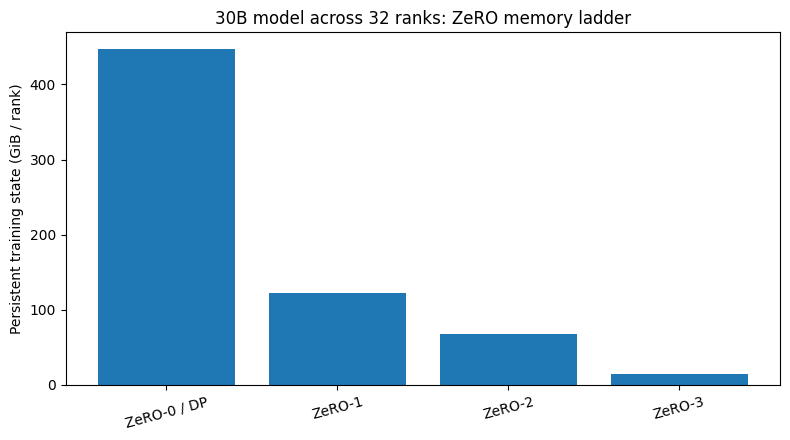

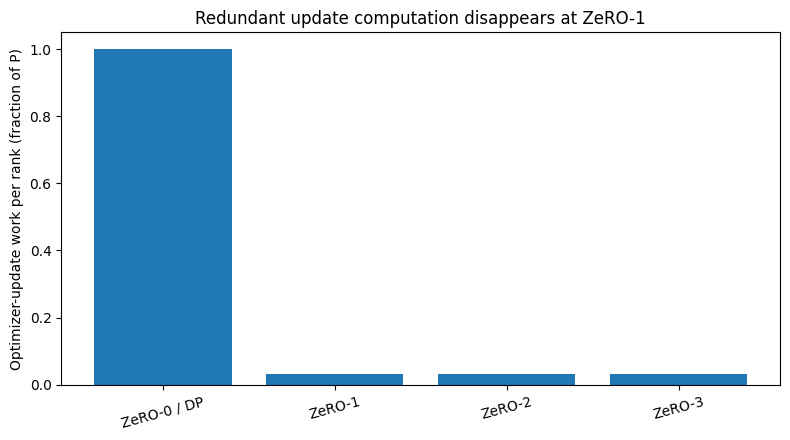

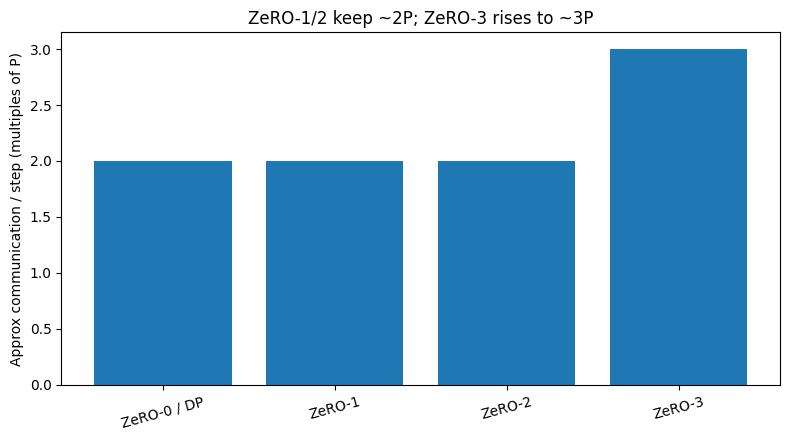

In [9]:

labels = [r["stage"] for r in rows]

plt.figure(figsize=(8,4.5))
plt.bar(labels, [r["30B_GiB_per_rank"] for r in rows])
plt.ylabel("Persistent training state (GiB / rank)")
plt.title("30B model across 32 ranks: ZeRO memory ladder")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("zero_memory_32ranks.png", dpi=160)
plt.show()

plt.figure(figsize=(8,4.5))
plt.bar(labels, [r["optimizer_update_params_per_rank"]/P for r in rows])
plt.ylabel("Optimizer-update work per rank (fraction of P)")
plt.title("Redundant update computation disappears at ZeRO-1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("zero_update_work.png", dpi=160)
plt.show()

plt.figure(figsize=(8,4.5))
plt.bar(labels, [r["communication_P_per_step"] for r in rows])
plt.ylabel("Approx communication / step (multiples of P)")
plt.title("ZeRO-1/2 keep ~2P; ZeRO-3 rises to ~3P")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("zero_communication.png", dpi=160)
plt.show()



## 7. What changes in computation?

### ZeRO-0 / ordinary data parallel
- each rank runs forward/backward on local data;
- full model, gradients, and optimizer state are replicated;
- gradients are all-reduced;
- all 32 ranks redundantly update all \(P\) parameters;
- cluster-wide optimizer update work is ~\(32P\).

### ZeRO-1
- forward/backward is still data parallel;
- weights and gradients remain replicated;
- optimizer/master state is partitioned;
- each rank updates only \(P/32\) parameters;
- updated shards are gathered;
- optimizer-update work becomes \(P/32\) per rank;
- communication remains ~\(2P\).

### ZeRO-2
- forward/backward arithmetic remains the same;
- gradients are reduce-scattered;
- each rank keeps only its \(P/32\) gradient shard;
- each rank updates only its owned shard;
- parameters are gathered afterward;
- communication remains ~\(2P\).

### ZeRO-3
- parameters are persistently sharded;
- a layer's parameters are all-gathered when that layer executes;
- after use, non-owned materialization can be released;
- gradients are reduce-scattered;
- each rank updates only its owned shard;
- persistent memory approaches \(16P/32\) bytes/rank;
- extra parameter gathering raises communication to ~\(3P\).

**Key insight:** ZeRO does not make the neural network's forward/backward FLOPs 32x cheaper. It removes redundant state storage and redundant optimizer-update work, while trading sharding for communication.


In [10]:

events = {
    "ZeRO-0 / DP": [
        "32 ranks: local forward/backward",
        "ALL-REDUCE full gradients",
        "32 ranks: each updates full P",
    ],
    "ZeRO-1": [
        "32 ranks: local forward/backward",
        "REDUCE-SCATTER gradients",
        "rank k updates optimizer/parameter shard k",
        "ALL-GATHER updated parameter shards",
    ],
    "ZeRO-2": [
        "32 ranks: local forward/backward",
        "REDUCE-SCATTER gradients; keep only owned shard",
        "rank k updates owned shard",
        "ALL-GATHER updated parameter shards",
    ],
    "ZeRO-3": [
        "for each layer: ALL-GATHER parameter shards",
        "local forward/backward for that layer",
        "REDUCE-SCATTER gradient shards",
        "release non-owned layer materialization",
        "rank k updates owned persistent shard",
    ],
}
for stage in STAGES:
    print("\n" + stage)
    for i, e in enumerate(events[stage], 1):
        print(f"  {i}. {e}")



ZeRO-0 / DP
  1. 32 ranks: local forward/backward
  2. ALL-REDUCE full gradients
  3. 32 ranks: each updates full P

ZeRO-1
  1. 32 ranks: local forward/backward
  2. REDUCE-SCATTER gradients
  3. rank k updates optimizer/parameter shard k
  4. ALL-GATHER updated parameter shards

ZeRO-2
  1. 32 ranks: local forward/backward
  2. REDUCE-SCATTER gradients; keep only owned shard
  3. rank k updates owned shard
  4. ALL-GATHER updated parameter shards

ZeRO-3
  1. for each layer: ALL-GATHER parameter shards
  2. local forward/backward for that layer
  3. REDUCE-SCATTER gradient shards
  4. release non-owned layer materialization
  5. rank k updates owned persistent shard



## 8. Final model-output correctness check


In [11]:

models = []
for flat in [updated0, updated1, updated2, updated3]:
    m = DemoMLP().to(DEVICE)
    assign_flat_params(m, flat)
    models.append(m)

x_test, y_test = rank_batches[0]
with torch.no_grad():
    logits_all = [m(x_test) for m in models]
    losses = [F.cross_entropy(z, y_test).item() for z in logits_all]

print("post-update losses:", [f"{x:.9f}" for x in losses])
for z in logits_all[1:]:
    assert torch.equal(logits_all[0], z)
print("✓ All strategies produce bit-identical demo-model outputs after the simulated step.")


post-update losses: ['2.130857944', '2.130857944', '2.130857944', '2.130857944']
✓ All strategies produce bit-identical demo-model outputs after the simulated step.



## 9. Summary

1. **Data parallelism solves throughput before memory.** More replicas do not reduce training-state memory per GPU. They increase parallel processing of training data by replicating the model over N (8) GPUs, giving the ability to train on Nx (8x) samples at the same time vs a single model copy on a single GPU.
2. **ZeRO-1 first removes redundant optimizer state.**: reduces the GPU memory requirement per GPU by reducing the amount of optimizer storage to 1/8th for 8 GPUs. Optimizer state stores first and second moment per weight, and the FP32 master copy of all weights. In ZeRO-1, these three values per weight, for 1/8th of the weights, are stored per GPU.
3. **ZeRO-2 also removes redundant gradients.** In the Session 12 30B example this reaches ~68.1 GiB/rank at 32 GPUs, before activations. On top of the three values per weight being split across GPUs in ZeRO-1, ZeRO-2 also splits the gradients per weight across the GPUs. Hence, now 4 values per weight are being split across the GPUs - the gradients, fp32 master weights, and Adam first and second moments are sharded.
4. **ZeRO-3 is qualitatively different because the model itself is sharded.** It must reconstruct layers when they execute. ZeRO-3 extends ZeRO-2 by partitioning the model weights themselves across the GPUs. For 8 GPUs, each GPU permanently stores only 1/8 of all the 5 components: 1/8 of the model weights, 1/8 of the gradients, and 1/8 of the optimizer state. This means that all major training-state components are now sharded.
5. **ZeRO-3 is 3P and not 2P**: ZeRO-3 changes what has to be communicated. For ZeRO-2, every GPU still permanently stores the full model weights. So during a training step, communication is roughly P (reduce-scatter grads) + P (all-gather updated weights). ZeRO-3 does not keep the full model on every GPU. Each GPU owns only its parameter shard. ZeRO-3 adds weight gathering during both forward and backward, increasing total communication by about 50%.
6. **Stages 1 and 2 are attractive because they stay in the same ~2P communication class as data parallelism.** Stage 3 pays ~3P.
7. **Forward/backward model math is not 32x cheaper.** The big compute saving shown here is removal of 32 redundant full optimizer updates.
8. **Persistent and transient memory are different.** ZeRO-3 can persist only 1/32 of state but still needs temporary layer materialization.
9. **This is not a 32-real-GPU performance benchmark.** One T4 cannot reproduce NVLink/InfiniBand latency, contention, or overlap. This notebook demonstrates ownership, memory, communication accounting, and mathematical equivalence.


In [12]:

results = {
    "world_size": WORLD_SIZE,
    "physical_device": str(DEVICE),
    "hardware": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else (platform.processor() or platform.machine()),
    "demo_model_parameters": P,
    "local_batch": LOCAL_BATCH,
    "global_batch": WORLD_SIZE * LOCAL_BATCH,
    "mean_local_loss_before_update": float(np.mean(local_losses)),
    "global_grad_norm": float(global_grad.norm().item()),
    "memory": rows,
    "correctness": {
        "max_diff_zero0_zero1": float((updated0-updated1).abs().max().item()),
        "max_diff_zero0_zero2": float((updated0-updated2).abs().max().item()),
        "max_diff_zero0_zero3": float((updated0-updated3).abs().max().item()),
        "post_update_losses": losses,
    }
}
Path("session12_results.json").write_text(json.dumps(results, indent=2))
print(json.dumps(results, indent=2))


{
  "world_size": 32,
  "physical_device": "cuda",
  "hardware": "Tesla T4",
  "demo_model_parameters": 6792,
  "local_batch": 8,
  "global_batch": 256,
  "mean_local_loss_before_update": 2.0744453594088554,
  "global_grad_norm": 0.15712089836597443,
  "memory": [
    {
      "stage": "ZeRO-0 / DP",
      "bytes_per_param_rank": 16.0,
      "demo_KiB_per_rank": 106.125,
      "30B_GiB_per_rank": 447.0348358154297,
      "optimizer_update_params_per_rank": 6792,
      "cluster_update_redundancy_x": 32.0,
      "communication_P_per_step": 2.0
    },
    {
      "stage": "ZeRO-1",
      "bytes_per_param_rank": 4.375,
      "demo_KiB_per_rank": 29.0185546875,
      "30B_GiB_per_rank": 122.23608791828156,
      "optimizer_update_params_per_rank": 213,
      "cluster_update_redundancy_x": 1.0,
      "communication_P_per_step": 2.0
    },
    {
      "stage": "ZeRO-2",
      "bytes_per_param_rank": 2.4375,
      "demo_KiB_per_rank": 16.16748046875,
      "30B_GiB_per_rank": 68.10296326875687,